In [55]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [56]:
os.getuid()

1000

In [57]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

# end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
end_datetime_str = start_datetime_str = "2024-11-07 14-27-14"

# Full run at server
start_datetime_str = "2024-11-07 14-35-44"
end_datetime_str = "2024-11-08 04-58-17"

# Test
# end_datetime_str = start_datetime_str = "2024-11-08 08-42-09"

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False
                                )

df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,Linear Velocity [m/s],...,Image pixel 1193,Image pixel 1194,Image pixel 1195,Image pixel 1196,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path
0,0.000,0.50,None,0.50,1,1,red_cube,0,train,0.475357,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
1,0.000,0.55,None,1.05,1,1,red_cube,1,train,0.299329,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
2,0.165,0.35,None,1.40,1,1,red_cube,2,train,0.077997,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
3,0.330,0.20,None,1.60,1,1,red_cube,3,train,0.433088,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
4,0.495,0.15,None,1.75,1,1,red_cube,4,train,0.354036,...,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...


In [58]:
df.phase

0     train
1     train
2     train
3     train
4     train
      ...  
45     eval
46     eval
47     eval
48     eval
49     eval
Name: phase, Length: 179034, dtype: object

In [59]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size"]
df = pd.concat([df, tmp], axis=1)

In [60]:
df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,Linear Velocity [m/s],...,Image pixel 1197,Image pixel 1198,Image pixel 1199,absolute_path,exp_config,experiment_path,category,controller,is_reset_buffer,buffer_size
0,0.000,0.50,None,0.50,1,1,red_cube,0,train,0.475357,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,TD3,False,4000
1,0.000,0.55,None,1.05,1,1,red_cube,1,train,0.299329,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,TD3,False,4000
2,0.165,0.35,None,1.40,1,1,red_cube,2,train,0.077997,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,TD3,False,4000
3,0.330,0.20,None,1.60,1,1,red_cube,3,train,0.433088,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,TD3,False,4000
4,0.495,0.15,None,1.75,1,1,red_cube,4,train,0.354036,...,0.290196,0.290196,0.290196,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,RobotPursuit,TD3,False,4000


In [61]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           RobotPursuit
controller                  TD3
is_reset_buffer           False
buffer_size                4000
Name: 0, dtype: object

In [62]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

time  running_objective current_value  \
controller category      buffer_size                                           
SAC        LineFollowing 16000        1.815               -1.0          None   
           PushingObject 4000         0.660               -1.0          None   
                         16000        1.155               -1.0          None   
           RobotPursuit  4000         1.155               -1.0          None   
                         16000        7.953               -1.0          None   
TD3        LineFollowing 4000         1.650               -1.0          None   
                         16000        2.640               -1.0          None   
           PushingObject 4000         2.805                0.0          None   
                         16000        2.145               -1.0          None   
           RobotPursuit  4000         8.679               -1.0          None   
                         16000        3.993               -1.0          None   

                                      current_undiscounted_value  episode_id  \
controller category      buffer_size                                           
SAC        LineFollowing 16000                          1.408163           1   
           PushingObject 4000                           0.350000           1   
                         16000                          0.940476           1   
           RobotPursuit  4000                           1.571429           1   
                         16000                         37.000127           1   
TD3        LineFollowing 4000                           3.571429           1   
                         16000                          0.551020           1   
           PushingObject 4000                          10.150370           1   
                         16000                          5.765628           1   
           RobotPursuit  4000                          26.860213           1   
                         16000                         16.870909           1   

                                      iteration_id        task_name  step_id  \
controller category      buffer_size                                           
SAC        LineFollowing 16000                 573    circle_yellow       82   
           PushingObject 4000                 1263           yellow       54   
                         16000                 905           yellow       55   
           RobotPursuit  4000                  454  yellow_cylinder       77   
                         16000                 669  yellow_cylinder       89   
TD3        LineFollowing 4000                 1443    circle_yellow       79   
                         16000                 645    circle_yellow       81   
           PushingObject 4000                 2596           yellow       80   
                         16000                2566           yellow       61   
           RobotPursuit  4000                 2518  yellow_cylinder       89   
                         16000                2602  yellow_cylinder       57   

                                     phase  Linear Velocity [m/s]  ...  \
controller category      buffer_size                               ...   
SAC        LineFollowing 16000        eval               0.286980  ...   
           PushingObject 4000         eval               0.342747  ...   
                         16000        eval               0.325332  ...   
           RobotPursuit  4000         eval               0.340338  ...   
                         16000        eval               0.036764  ...   
TD3        LineFollowing 4000         eval               0.387047  ...   
                         16000        eval               0.409604  ...   
           PushingObject 4000         eval               0.050641  ...   
                         16000        eval               0.038644  ...   
           RobotPursuit  4000         eval               0.389617  ...   
                         160

In [63]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'LineFollowing', 16000))

In [64]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'LineFollowing', 16000),
            ('SAC', 'PushingObject',  4000),
            ('SAC', 'PushingObject', 16000),
            ('SAC',  'RobotPursuit',  4000),
            ('SAC',  'RobotPursuit', 16000),
            ('TD3', 'LineFollowing',  4000),
            ('TD3', 'LineFollowing', 16000),
            ('TD3', 'PushingObject',  4000),
            ('TD3', 'PushingObject', 16000),
            ('TD3',  'RobotPursuit',  4000),
            ('TD3',  'RobotPursuit', 16000)],
           names=['controller', 'category', 'buffer_size'])

In [65]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

/tmp/ipykernel_434700/2743105663.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[group_df.index[0]]


In [66]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [67]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/tcc/huyhoang/irlc_2025/regelum-playground-iclr/venv/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_434700/42267152.py:9: PerformanceWarning: index

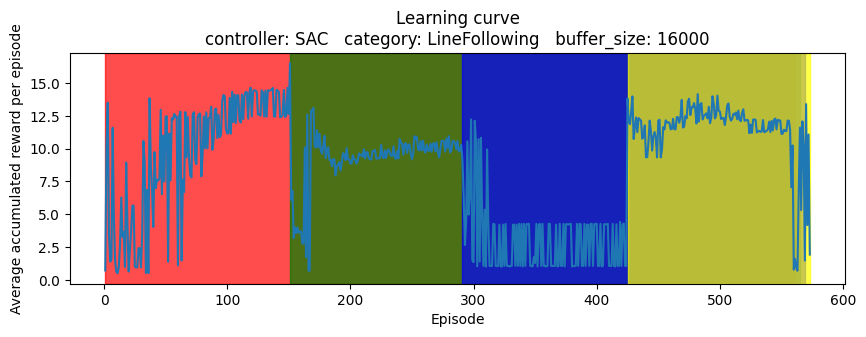

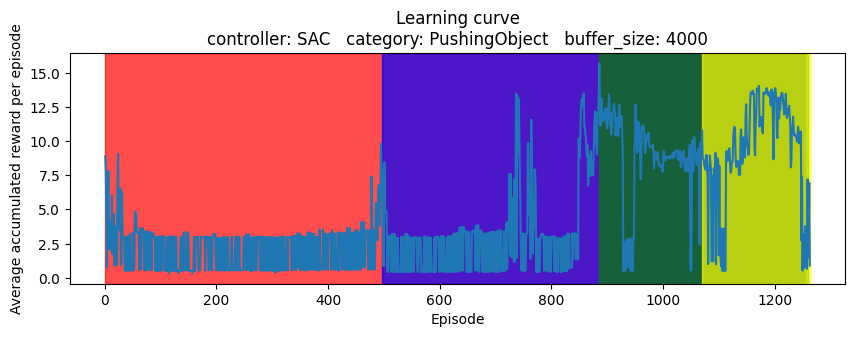

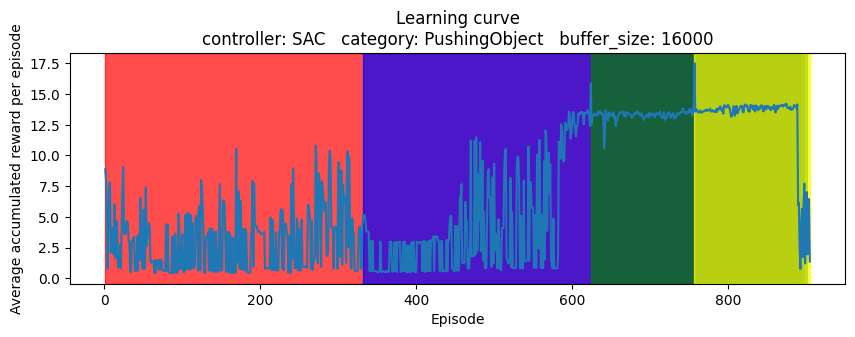

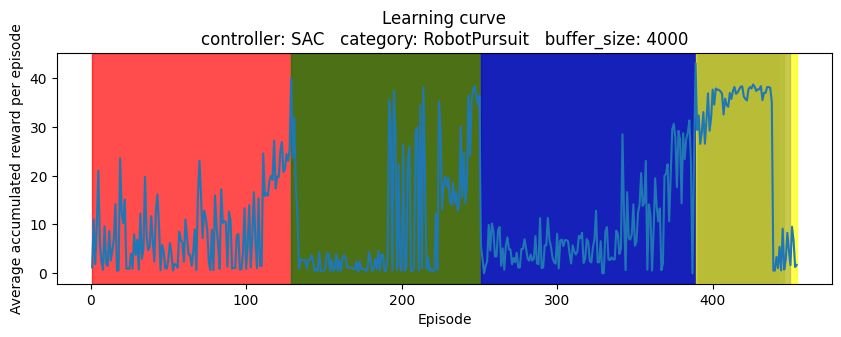

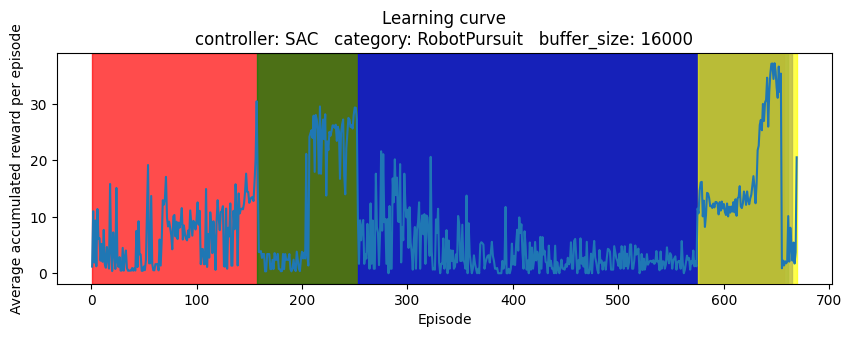

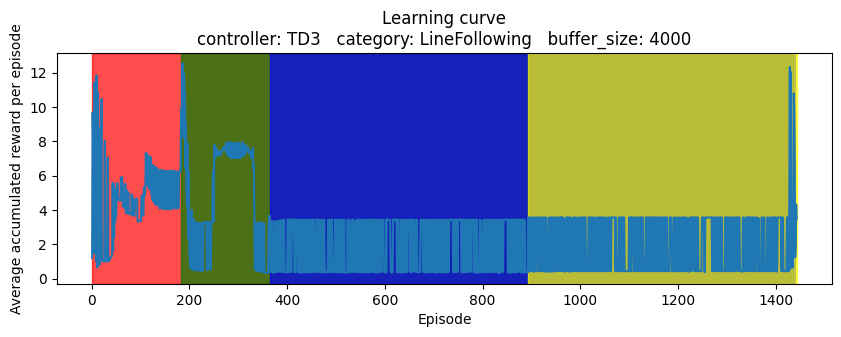

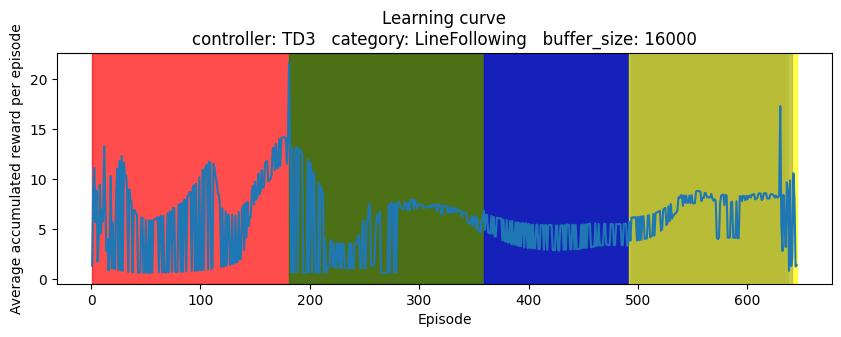

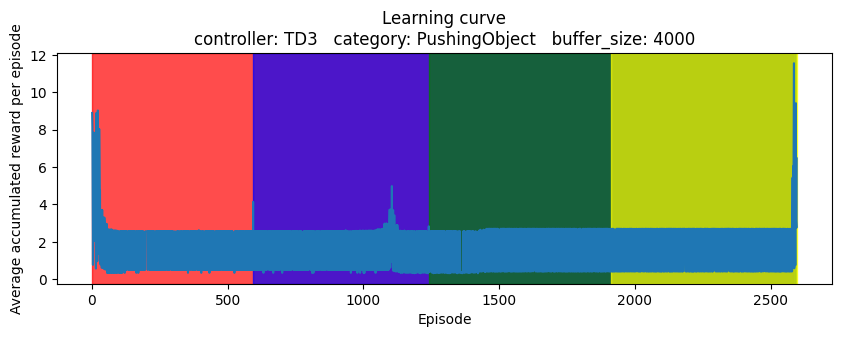

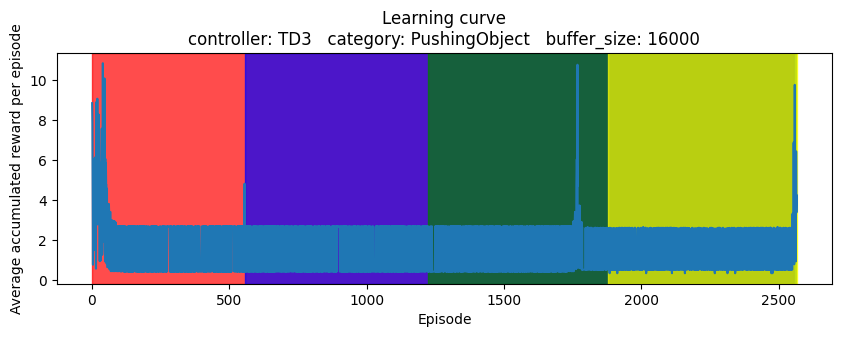

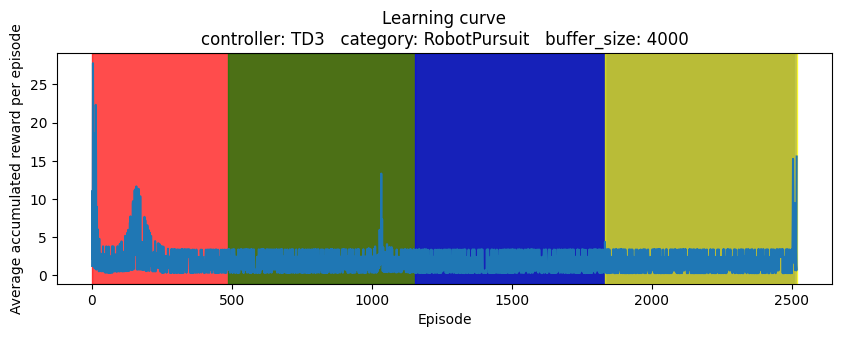

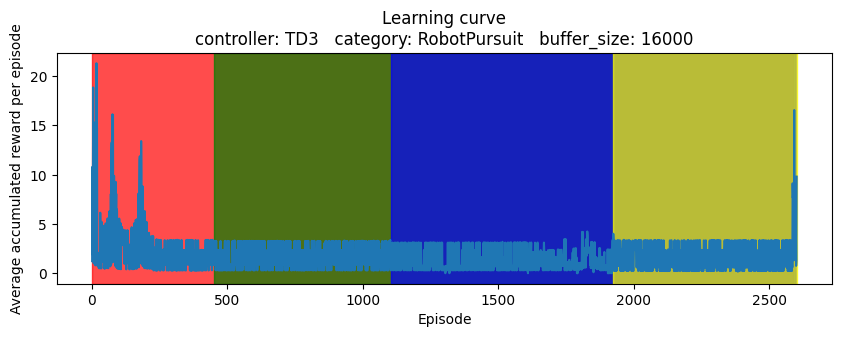

In [68]:
import matplotlib.pyplot as plt
# import matplotlib
# %matplotlib inline

def plot_learning_curve(index, index_names, df):
    fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value"]].groupby("iteration_id")
    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "mean", 
        "task_name": "last",
        "step_id": "last"
        })
    tmp_group_df.plot(y="current_undiscounted_value", ax=ax)

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.7, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Average accumulated reward per episode')
    ax.set_title(
        'Learning curve\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()


for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df)
# plot_learning_curve(group_df.index[1], group_df.index.names, df)
# plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
# plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
# plt.show()

In [76]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df[df.running_objective == 10].loc[['SAC']]

index   time  \
controller category      buffer_size task_name                 
SAC        PushingObject 4000        blue          29  4.620   
                                     blue          28  4.455   
                                     blue          28  4.455   
                                     blue          25  3.960   
                                     blue          25  3.960   
...                                               ...    ...   
                                     yellow        21  3.300   
                                     yellow        23  3.630   
                                     yellow        23  3.630   
                         16000       blue          22  3.465   
                                     yellow        24  3.795   

                                                running_objective  \
controller category      buffer_size task_name                      
SAC        PushingObject 4000        blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
                                     blue                    10.0   
...                                                           ...   
                                     yellow                  10.0   
                                     yellow                  10.0   
                                     yellow                  10.0   
                         16000       blue                    10.0   
                                     yellow                  10.0   

                                               current_value  \
controller category      buffer_size task_name                 
SAC        PushingObject 4000        blue               None   
                                     blue               None   
                                     blue               None   
                                     blue               None   
                                     blue               None   
...                                                      ...   
                                     yellow             None   
                                     yellow             None   
                                     yellow             None   
                         16000       blue               None   
                                     yellow             None   

                                                current_undiscounted_value  \
controller category      buffer_size task_name                               
SAC        PushingObject 4000        blue                        34.824917   
                                     blue                        33.383945   
                                     blue                        28.723919   
                                     blue                        28.518192   
                                     blue                        28.521211   
...                                                                    ...   
                                     yellow                      27.991566   
                                     yellow                      29.448375   
                                     yellow                      29.458102   
                         16000       blue                        23.354346   
                                     yellow                      22.186957   

                                                episode_id  iteration_id  \
controller category      buffer_size task_name                             
SAC        PushingObject 4000        blue                1           741   
                                     blue                1           742   
                                     blue                1           743   
                                     blue                1           758   
             

<Axes: xlabel='iteration_id'>

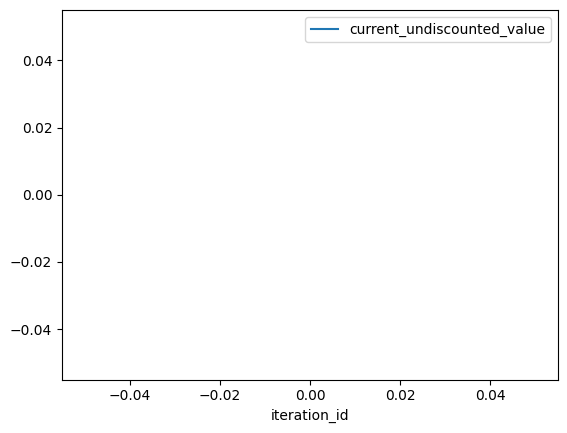

In [ ]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index]

tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "phase"]].groupby("iteration_id")
tmp_group_df = tmp_group_df.aggregate({
    "current_undiscounted_value": "mean", 
    "task_name": "last",
    "step_id": "last",
    "phase": "last"
    })
tmp_group_df[tmp_group_df.phase=="eval"].plot(y="current_undiscounted_value")

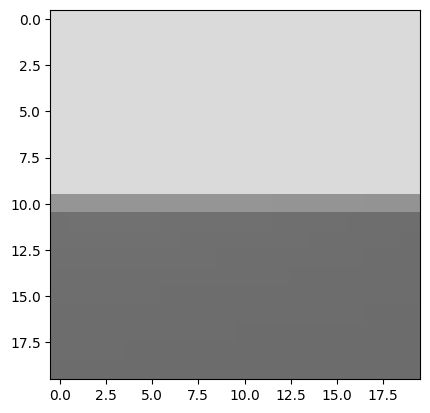

In [39]:
# df = df.reset_index()
pixel_columns = [c for c in df.columns if "pixel" in c.lower()]
chosen_state = np.array(df.loc[:, pixel_columns].iloc[-1])
im = chosen_state.reshape((20, 20, 3))

plt.imshow(im)

In [40]:
# from src.objective import RobotPursuitRunningObjective

# objective_func = RobotPursuitRunningObjective()

# objective_func(state=im, 
#                catcher_pos=[1, 1], 
#                runner_pos=[0, 0], 
#                action=[1, 0], 
#                step_count=0, 
#                max_steps_per_episode=100,
#                runner_collision_thickness=0.49,
#                arena_bounds=[-2.5,2.5,-2.5,2.5],
#                info={})

In [41]:
import numpy as np
np.sum(im)

779.74115

KeyError: ('SAC', 'LineFollowing', False)

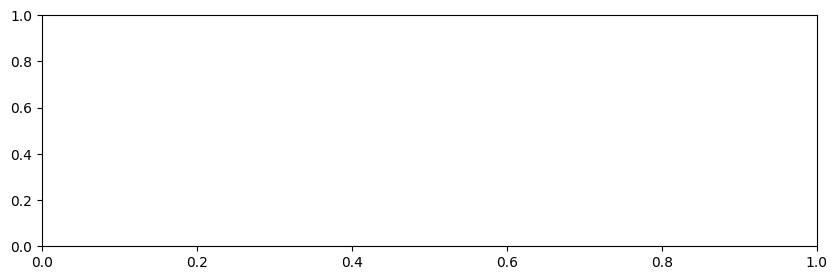

In [42]:
plot_learning_curve(('SAC', 'LineFollowing', False), group_df.index.names, df)
plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)

In [ ]:
tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]
tmp_df[(tmp_df.step_id.diff() < 0)]
# tmp_df.step_id.values.tolist()[1:]+ [tmp_df.step_id.values.tolist()[-1]]

/tmp/ipykernel_127043/3476527340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]


index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                6  0.000           0.408163   
                         False                8  0.198           0.000000   
                         False                9  0.363           0.000000   
                         False               10  0.528           0.000000   
                         False               11  0.693           0.000000   
                         False                2  0.000           0.693878   
                         False               15  0.000           0.734694   
                         False               18  0.363           0.979592   
                         False               19  0.528           0.979592   
                         False               20  0.693           0.897959   
                         False               21  0.858           0.775510   
                         False               22  1.023           0.530612   
                         False               23  1.188           0.285714   
                         False               24  1.353           0.081633   
                         False               25  1.518           0.040816   
                         False               26  1.683          -1.000000   
                         False                0  0.000           0.530612   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer                               
SAC        LineFollowing False                              2.693878   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.122449   
                         False                              5.755102   
                         False                              8.448980   
                         False                              9.428571   
                         False                             10.326531   
                         False                             11.102041   
                         False                             11.632653   
                         False                             11.918367   
                         False                             12.000000   
                         False                             12.040816   
                         False                             11.040816   
                         False                              0.530612   

                                          episode_id  iteration_id  \
controller category      is_reset_bu

In [ ]:
tmp_df[tmp_df.iteration_id == 1196]

index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                0  0.000           0.693878   
                         False                1  0.000           0.857143   
                         False               15  0.000           0.734694   
                         False               16  0.000           0.775510   
                         False               17  0.165           0.938776   
                         False                2  0.198           0.979592   
                         False                3  0.363           0.775510   
                         False               18  0.363           0.979592   
                         False                4  0.528           0.408163   
                         False               19  0.528           0.979592   
                         False                5  0.693           0.448980   
                         False               20  0.693           0.897959   
                         False                6  0.858           0.326531   
                         False               21  0.858           0.775510   
                         False                7  1.023           0.122449   
                         False               22  1.023           0.530612   
                         False                8  1.188           0.040816   
                         False               23  1.188           0.285714   
                         False                9  1.353           0.040816   
                         False               24  1.353           0.081633   
                         False               10  1.518           0.040816   
                         False               25  1.518           0.040816   
                         False               11  1.683           0.000000   
                         False               26  1.683          -1.000000   
                         False               12  1.848           0.081633   
                         False               13  2.013           0.081633   
                         False               14  2.178           0.122449   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer             